In [1]:
# core
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# stats
from scipy.stats import spearmanr

# plot style
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

# optional: wider plots
plt.rcParams["figure.figsize"] = (12, 6)

In [5]:
# load data
def load_portfolio_diagnostics(name, path="data/diagnostics"):
    pnl = pd.read_parquet(f"{path}/{name}_pnl.parquet")
    weights = pd.read_parquet(f"{path}/{name}_weights.parquet")
    turnover = pd.read_parquet(f"{path}/{name}_turnover.parquet")
    stats = pd.read_parquet(f"{path}/{name}_stats.parquet")
    returns = pd.read_parquet(f"{path}/{name}_returns.parquet")

    # optional
    try:
        sleeve_alloc = pd.read_parquet(f"{path}/{name}_sleeve_alloc.parquet")
    except:
        sleeve_alloc = None

    try:
        sleeve_pnls = pd.read_parquet(f"{path}/{name}_sleeve_pnls.parquet")
    except:
        sleeve_pnls = None

    return {
        "pnl": pnl,
        "weights": weights,
        "turnover": turnover,
        "stats": stats,
        "returns": returns,
        "sleeve_alloc": sleeve_alloc,
        "sleeve_pnls": sleeve_pnls
    }

# Utils
def performance_stats(pnl):
    pnl = pnl.dropna()

    ann = 252
    sharpe = pnl.mean() / pnl.std() * np.sqrt(ann) if pnl.std() != 0 else np.nan
    vol = pnl.std() * np.sqrt(ann)
    total_return = (1 + pnl).prod() - 1
    cum = (1 + pnl).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    skew = pnl.skew()

    return {
        "PnL": total_return,
        "Sharpe": sharpe,
        "Vol": vol,
        "MaxDD": max_dd,
        "Skew": skew,
    }


def compute_drawdown(pnl):
    cum = (1 + pnl).cumprod()
    dd = cum / cum.cummax() - 1
    return dd


def compute_rolling_sharpe(pnl, window=126):
    return (
        pnl.rolling(window).mean()
        / pnl.rolling(window).std()
    ) * np.sqrt(252)

/var/folders/ps/45m3y3115p7b5b6r4qyk36pr0000gn/T/ipykernel_8073/75161283.py:72: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = pnl.resample("M").apply(lambda x: (1 + x).prod() - 1)


,Gross,Net
PnL,0.529874,0.351285
Sharpe,0.400607,0.291625
Vol,0.055375,0.055396
MaxDD,-0.155152,-0.158725
Skew,0.843623,0.838766


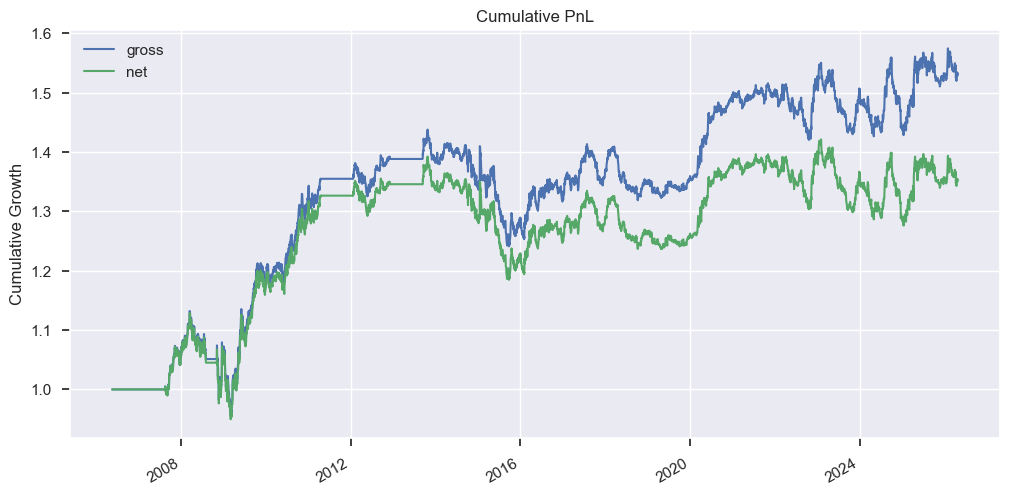

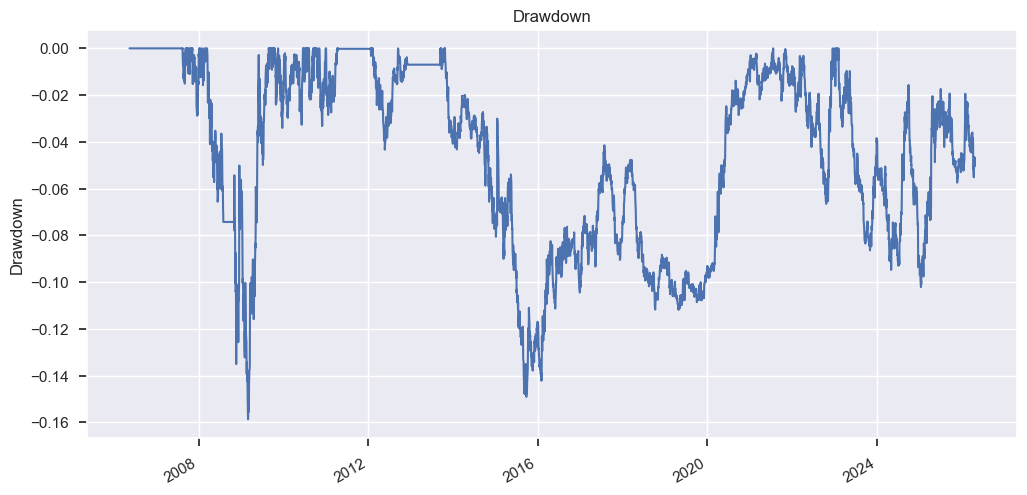

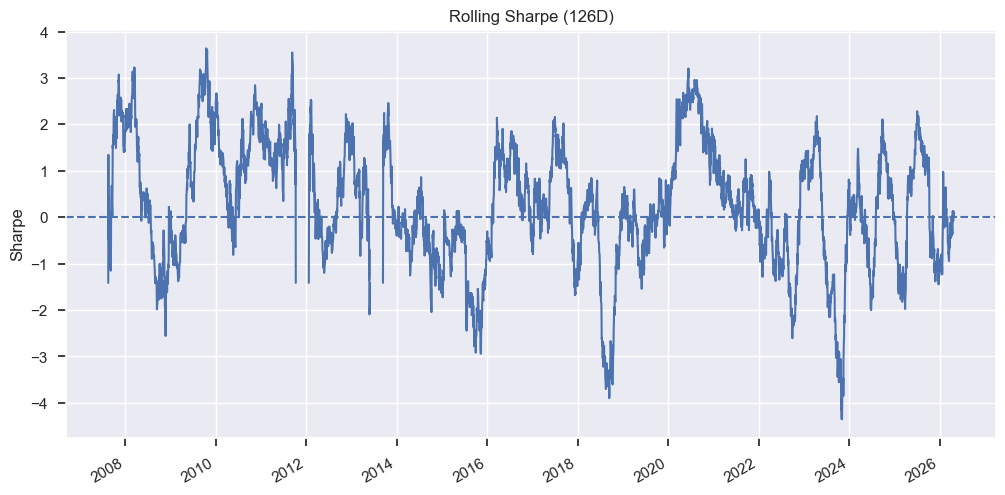

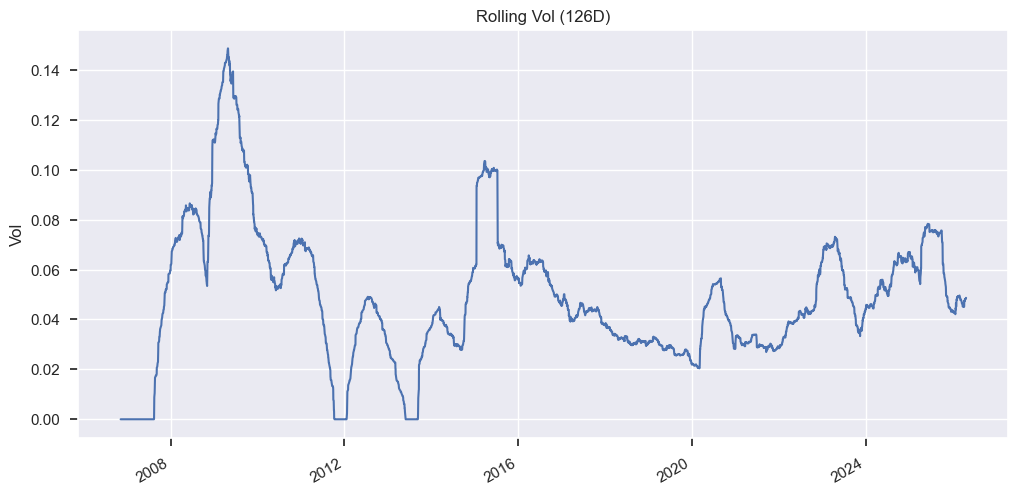

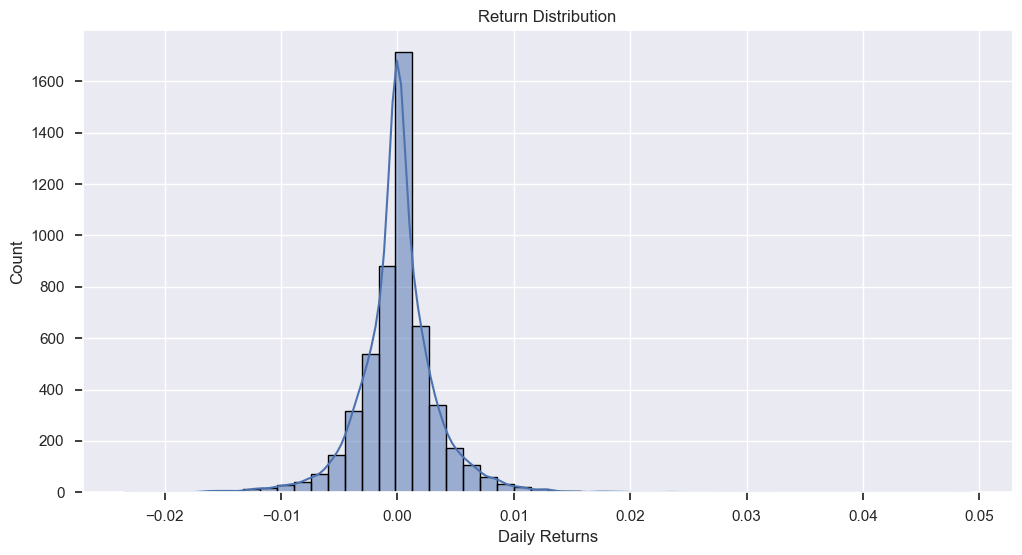

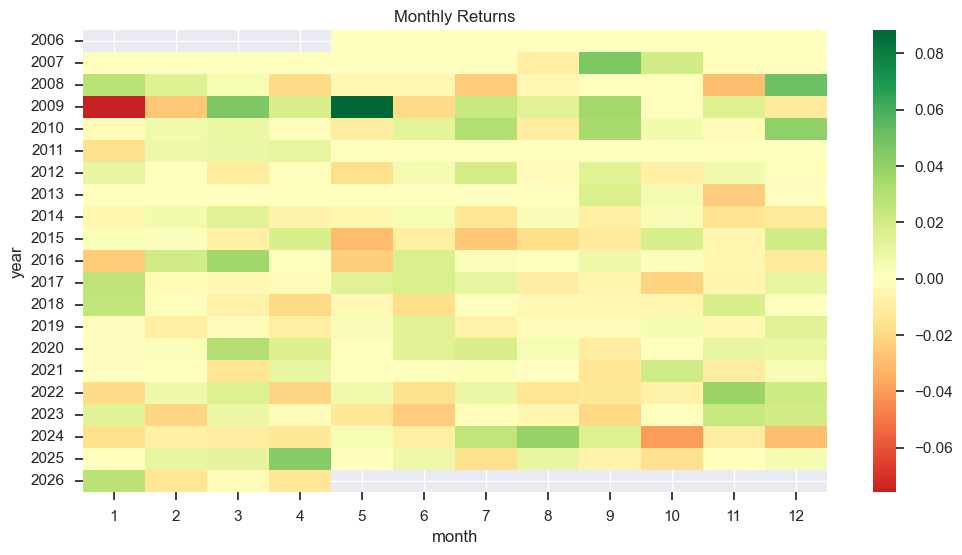

In [ ]:
# Portfolio Diagnostics

# CUMULATIVE PNL (GROSS VS NET)
def plot_cumulative_pnl(pnl_df, title="Cumulative PnL"):
    """
    pnl_df must have columns: ['gross', 'net']
    """
    cum = (1 + pnl_df).cumprod()

    fig, ax = plt.subplots()
    cum.plot(ax=ax)

    ax.set_title(title)
    ax.set_ylabel("Cumulative Growth")
    ax.legend()
    ax.grid(True)

    return fig

# DRAWDOWN
def plot_drawdowns(pnl, title="Drawdown"):
    dd = compute_drawdown(pnl)

    fig, ax = plt.subplots()
    dd.plot(ax=ax)

    ax.set_title(title)
    ax.set_ylabel("Drawdown")
    ax.grid(True)

    return fig

# ROLLING SHARPE
def plot_rolling_sharpe(pnl, window=126, title="Rolling Sharpe"):
    rs = compute_rolling_sharpe(pnl, window)

    fig, ax = plt.subplots()
    rs.plot(ax=ax)

    ax.axhline(0, linestyle="--")
    ax.set_title(f"{title} ({window}D)")
    ax.set_ylabel("Sharpe")
    ax.grid(True)

    return fig

# ROLLING VOLATILITY
def plot_rolling_vol(pnl, window=126, title="Rolling Vol"):
    vol = pnl.rolling(window).std() * np.sqrt(252)

    fig, ax = plt.subplots()
    vol.plot(ax=ax)

    ax.set_title(f"{title} ({window}D)")
    ax.set_ylabel("Vol")
    ax.grid(True)

    return fig

# RETURN DISTRIBUTION
def plot_return_distribution(pnl, title="Return Distribution"):
    fig, ax = plt.subplots()
    sns.histplot(pnl.dropna(), bins=50, kde=True, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Daily Returns")

    return fig

# MONTHLY RETURNS HEATMAP
def plot_monthly_returns_heatmap(pnl, title="Monthly Returns"):
    monthly = pnl.resample("M").apply(lambda x: (1 + x).prod() - 1)
    table = monthly.to_frame("ret")

    table["year"] = table.index.year
    table["month"] = table.index.month

    pivot = table.pivot(index="year", columns="month", values="ret")

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=False, ax=ax)

    ax.set_title(title)

    return fig

# PERFORMANCE SUMMARY TABLE
def display_performance_summary(pnl_df):
    gross = performance_stats(pnl_df["gross"])
    net = performance_stats(pnl_df["net"])

    df = pd.DataFrame({
        "Gross": gross,
        "Net": net
    })

    return df

diag = load_portfolio_diagnostics("ivol_scalar_overlay")

pnl_df = diag["pnl"]

# plots
plot_cumulative_pnl(pnl_df)
plot_drawdowns(pnl_df["net"])
plot_rolling_sharpe(pnl_df["net"])
plot_rolling_vol(pnl_df["net"])
plot_return_distribution(pnl_df["net"])
plot_monthly_returns_heatmap(pnl_df["net"])

# summary
display_performance_summary(pnl_df)

,Value
Avg Daily Turnover,0.047846
Annual Turnover,12.057246
Avg Daily Cost,0.000024
Annual Cost,0.006029
Gross Sharpe,0.400607
Net Sharpe,0.291625


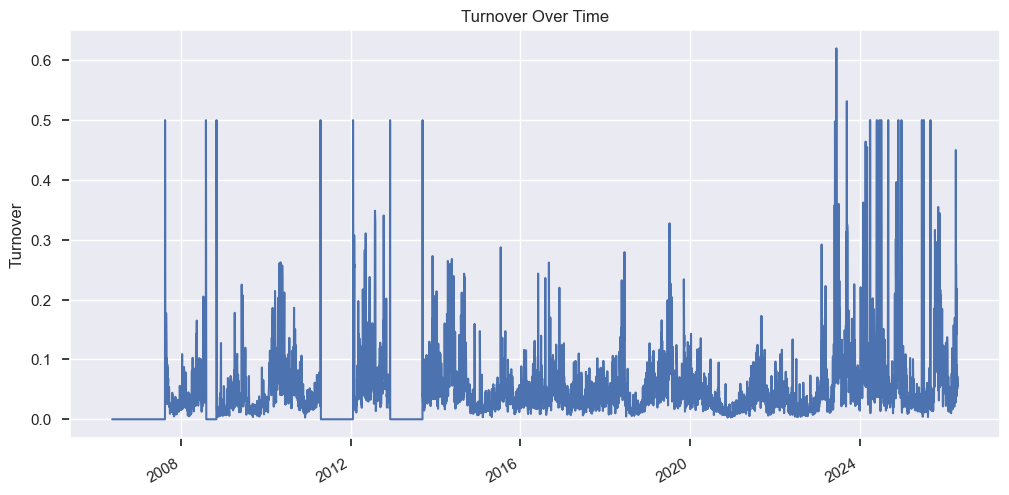

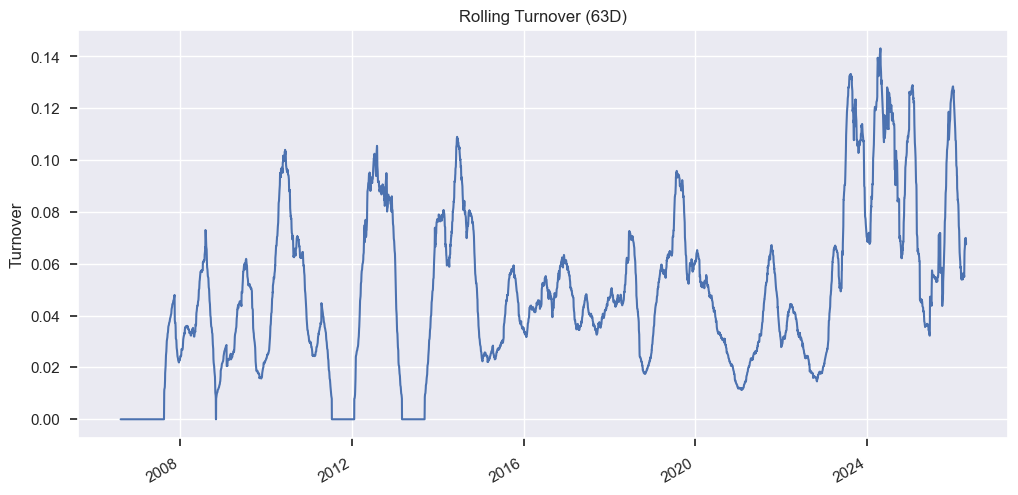

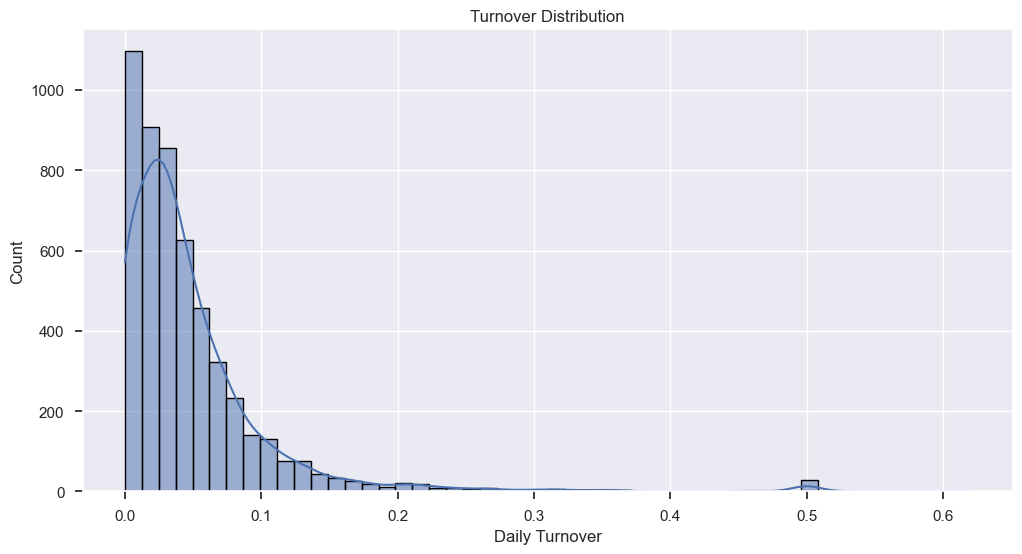

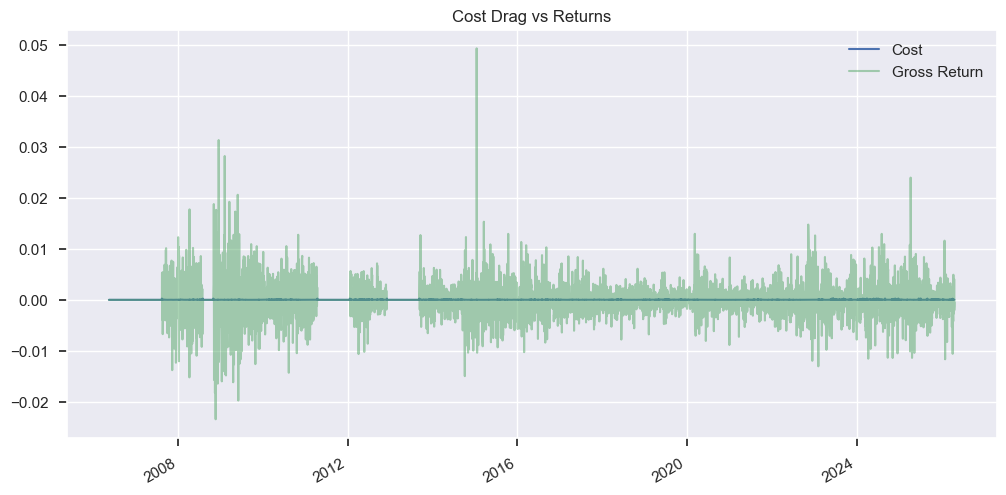

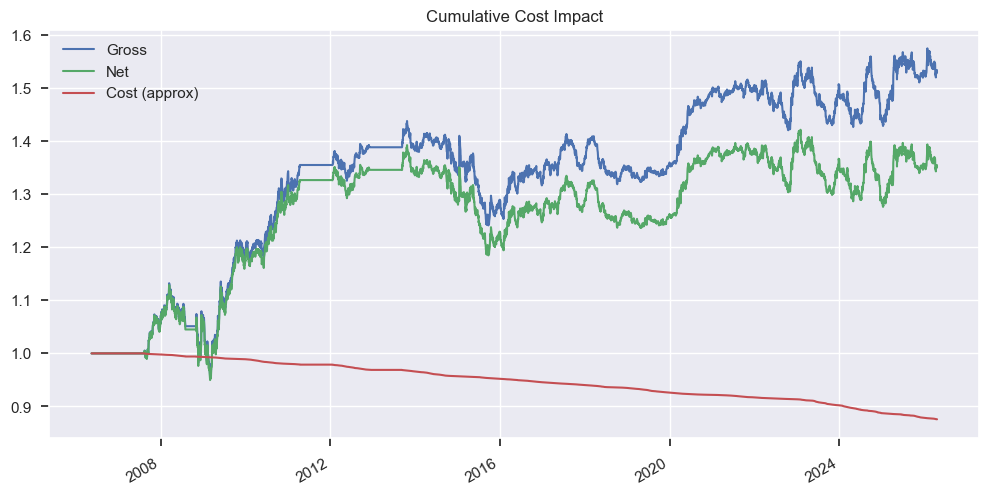

In [7]:
# Transaction Diagnositcs 

# TURNOVER TIME SERIES
def plot_turnover(turnover, title="Turnover Over Time"):
    fig, ax = plt.subplots()

    turnover.plot(ax=ax)

    ax.set_title(title)
    ax.set_ylabel("Turnover")
    ax.grid(True)

    return fig

# ROLLING TURNOVER
def plot_rolling_turnover(turnover, window=63):
    rt = turnover.rolling(window).mean()

    fig, ax = plt.subplots()
    rt.plot(ax=ax)

    ax.set_title(f"Rolling Turnover ({window}D)")
    ax.set_ylabel("Turnover")
    ax.grid(True)

    return fig

# TURNOVER DISTRIBUTION
def plot_turnover_distribution(turnover):
    fig, ax = plt.subplots()

    sns.histplot(turnover.dropna(), bins=50, kde=True, ax=ax)

    ax.set_title("Turnover Distribution")
    ax.set_xlabel("Daily Turnover")

    return fig

# COST DRAG TIME SERIES
def plot_cost_drag(pnl_df, turnover, cost_per_turnover=0.0005):
    cost = turnover * cost_per_turnover

    fig, ax = plt.subplots()

    cost.plot(ax=ax, label="Cost")
    pnl_df["gross"].plot(ax=ax, alpha=0.5, label="Gross Return")

    ax.set_title("Cost Drag vs Returns")
    ax.legend()
    ax.grid(True)

    return fig

# CUMULATIVE COST IMPACT
def plot_cumulative_cost_impact(pnl_df, turnover, cost_per_turnover=0.0005):
    cost = turnover * cost_per_turnover

    cum_cost = cost.cumsum()
    cum_gross = (1 + pnl_df["gross"]).cumprod()
    cum_net = (1 + pnl_df["net"]).cumprod()

    fig, ax = plt.subplots()

    cum_gross.plot(ax=ax, label="Gross")
    cum_net.plot(ax=ax, label="Net")
    (1 - cum_cost).plot(ax=ax, label="Cost (approx)")

    ax.set_title("Cumulative Cost Impact")
    ax.legend()
    ax.grid(True)

    return fig

# COST SUMMARY
def display_cost_summary(pnl_df, turnover, cost_per_turnover=0.0005):
    cost = turnover * cost_per_turnover

    avg_daily_turnover = turnover.mean()
    annual_turnover = avg_daily_turnover * 252

    avg_daily_cost = cost.mean()
    annual_cost = avg_daily_cost * 252

    gross_sharpe = performance_stats(pnl_df["gross"])["Sharpe"]
    net_sharpe = performance_stats(pnl_df["net"])["Sharpe"]

    df = pd.DataFrame({
        "Value": [
            avg_daily_turnover,
            annual_turnover,
            avg_daily_cost,
            annual_cost,
            gross_sharpe,
            net_sharpe
        ]
    }, index=[
        "Avg Daily Turnover",
        "Annual Turnover",
        "Avg Daily Cost",
        "Annual Cost",
        "Gross Sharpe",
        "Net Sharpe"
    ])

    return df

turnover = diag["turnover"]["turnover"]
pnl_df = diag["pnl"]

plot_turnover(turnover)
plot_rolling_turnover(turnover)
plot_turnover_distribution(turnover)

plot_cost_drag(pnl_df, turnover)
plot_cumulative_cost_impact(pnl_df, turnover)

display_cost_summary(pnl_df, turnover)

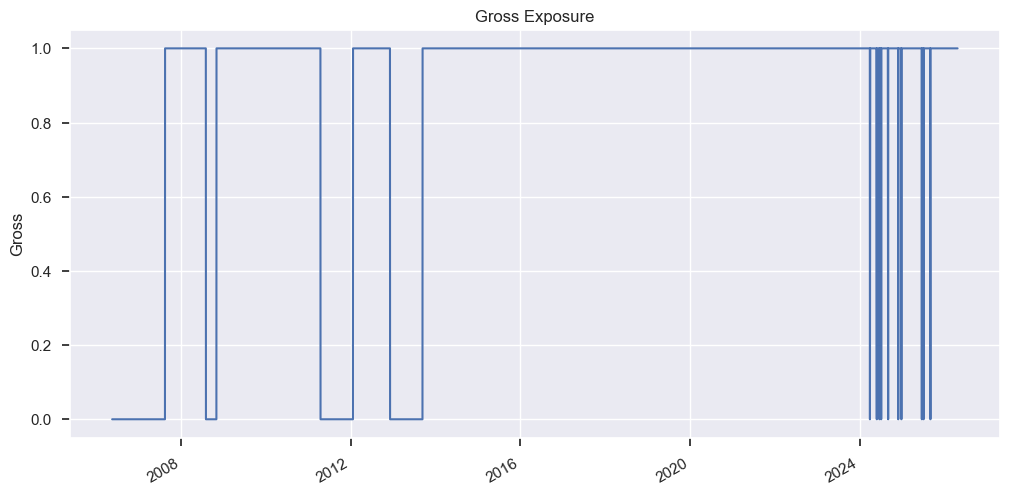

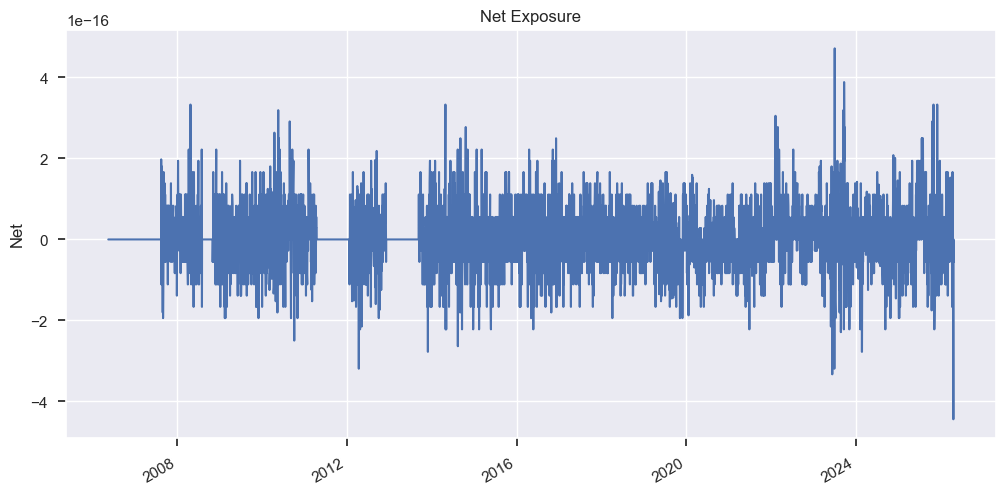

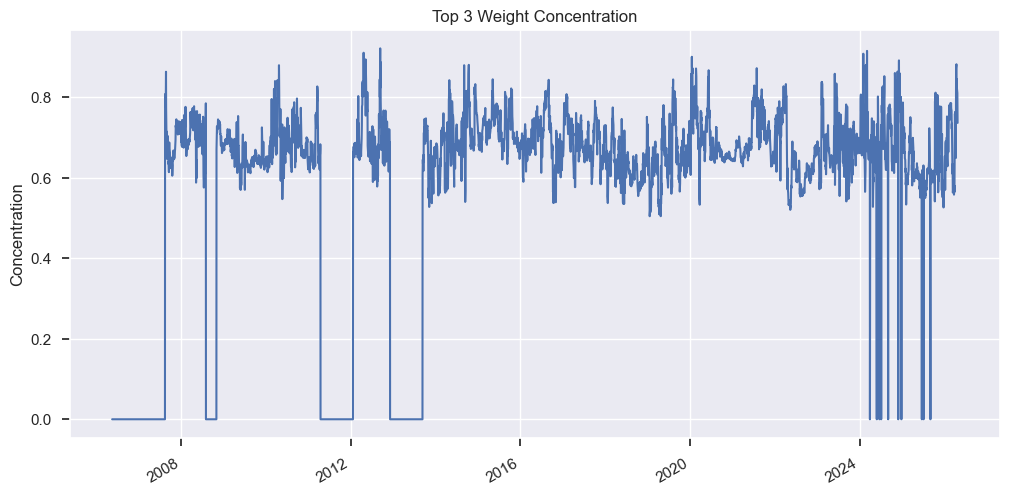

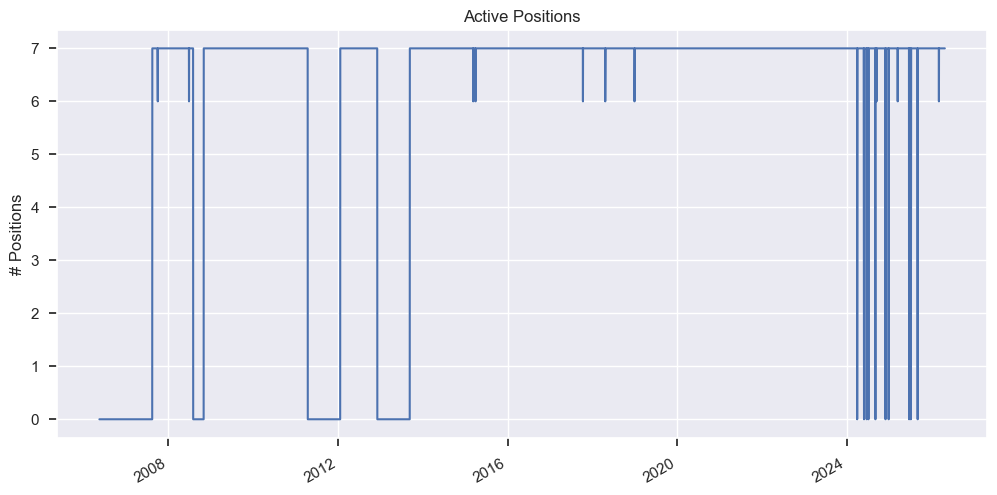

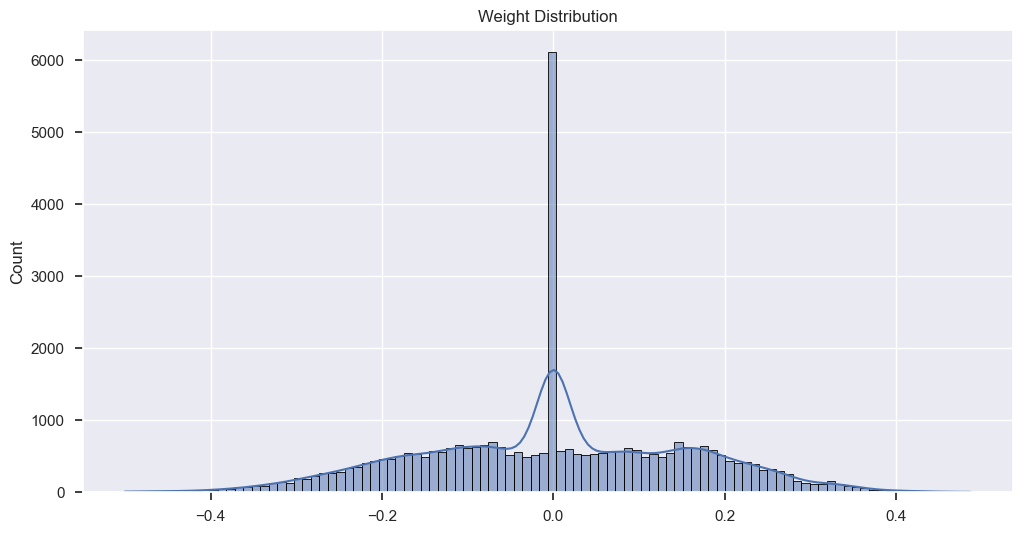

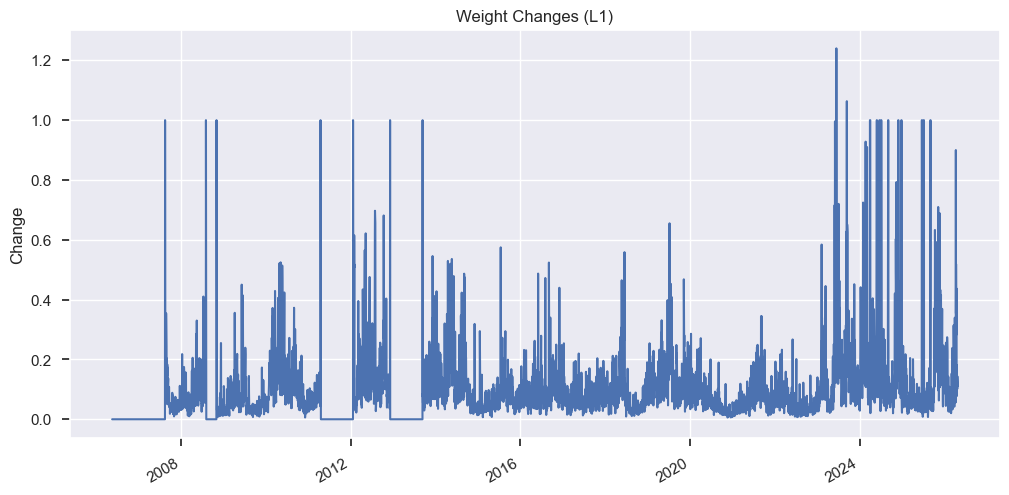

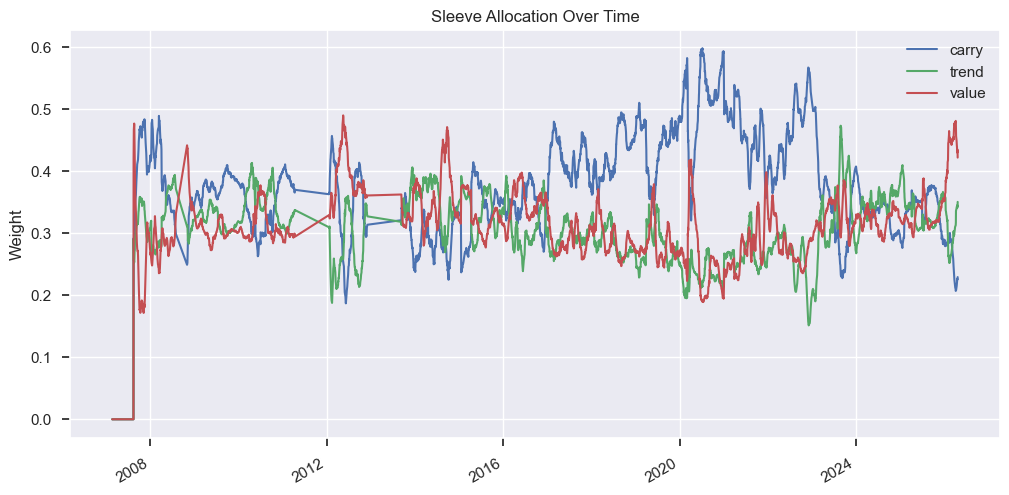

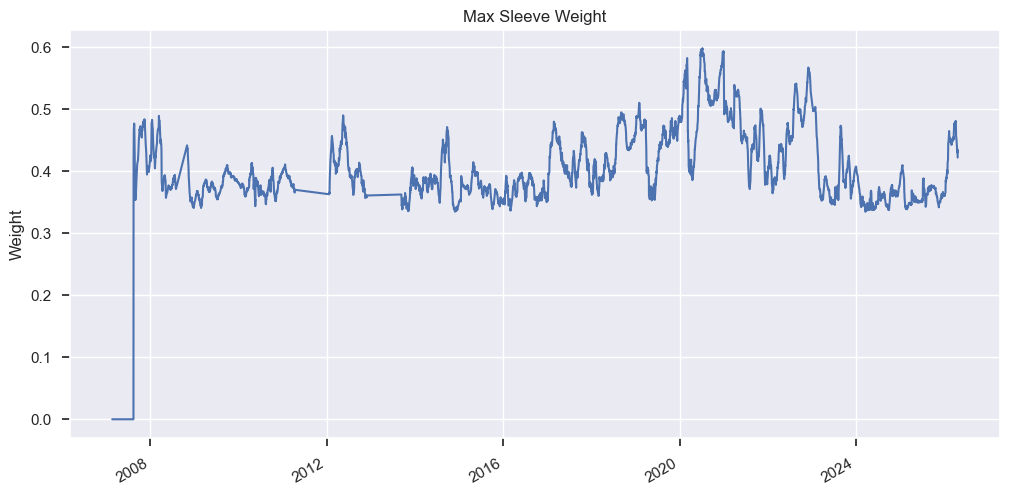

In [8]:
# Portfolio Structure Diagnostics

# GROSS EXPOSURE
def plot_gross_exposure(weights):
    gross = weights.abs().sum(axis=1)

    fig, ax = plt.subplots()
    gross.plot(ax=ax)

    ax.set_title("Gross Exposure")
    ax.set_ylabel("Gross")
    ax.grid(True)

    return fig


# NET EXPOSURE
def plot_net_exposure(weights):
    net = weights.sum(axis=1)

    fig, ax = plt.subplots()
    net.plot(ax=ax)

    ax.set_title("Net Exposure")
    ax.set_ylabel("Net")
    ax.grid(True)

    return fig

# TOP N WEIGHT CONCENTRATION
def plot_weight_concentration(weights, top_n=3):
    top_weights = weights.abs().apply(
        lambda row: row.nlargest(top_n).sum(),
        axis=1
    )

    fig, ax = plt.subplots()
    top_weights.plot(ax=ax)

    ax.set_title(f"Top {top_n} Weight Concentration")
    ax.set_ylabel("Concentration")
    ax.grid(True)

    return fig

# ACTIVE POSITION COUNT
def plot_active_positions(weights, threshold=1e-4):
    active = (weights.abs() > threshold).sum(axis=1)

    fig, ax = plt.subplots()
    active.plot(ax=ax)

    ax.set_title("Active Positions")
    ax.set_ylabel("# Positions")
    ax.grid(True)

    return fig

# WEIGHT DISTRIBUTION
def plot_weight_distribution(weights):
    fig, ax = plt.subplots()

    sns.histplot(weights.stack(), bins=100, kde=True, ax=ax)

    ax.set_title("Weight Distribution")

    return fig

# WEIGHT CHANGE (L1)
def plot_weight_changes(weights):
    changes = weights.diff().abs().sum(axis=1)

    fig, ax = plt.subplots()
    changes.plot(ax=ax)

    ax.set_title("Weight Changes (L1)")
    ax.set_ylabel("Change")
    ax.grid(True)

    return fig

# SLEEVE ALLOCATION
def plot_sleeve_allocation(sleeve_alloc):
    fig, ax = plt.subplots()

    sleeve_alloc.plot(ax=ax)

    ax.set_title("Sleeve Allocation Over Time")
    ax.set_ylabel("Weight")
    ax.legend()
    ax.grid(True)

    return fig

# SLEEVE CONCENTRATION
def plot_sleeve_concentration(sleeve_alloc):
    max_alloc = sleeve_alloc.max(axis=1)

    fig, ax = plt.subplots()
    max_alloc.plot(ax=ax)

    ax.set_title("Max Sleeve Weight")
    ax.set_ylabel("Weight")
    ax.grid(True)

    return fig

weights = diag["weights"]
sleeve_alloc = diag["sleeve_alloc"]

plot_gross_exposure(weights)
plot_net_exposure(weights)

plot_weight_concentration(weights)
plot_active_positions(weights)

plot_weight_distribution(weights)
plot_weight_changes(weights)

if sleeve_alloc is not None:
    plot_sleeve_allocation(sleeve_alloc)
    plot_sleeve_concentration(sleeve_alloc)

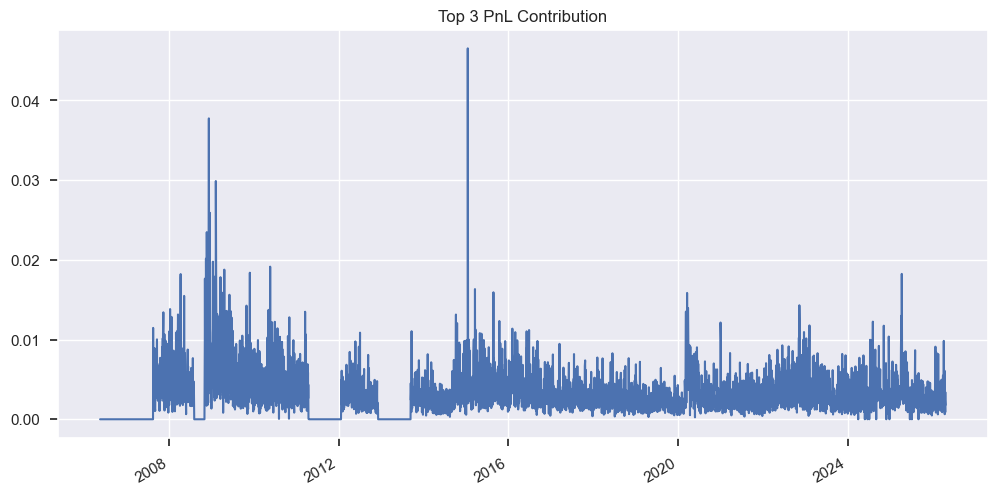

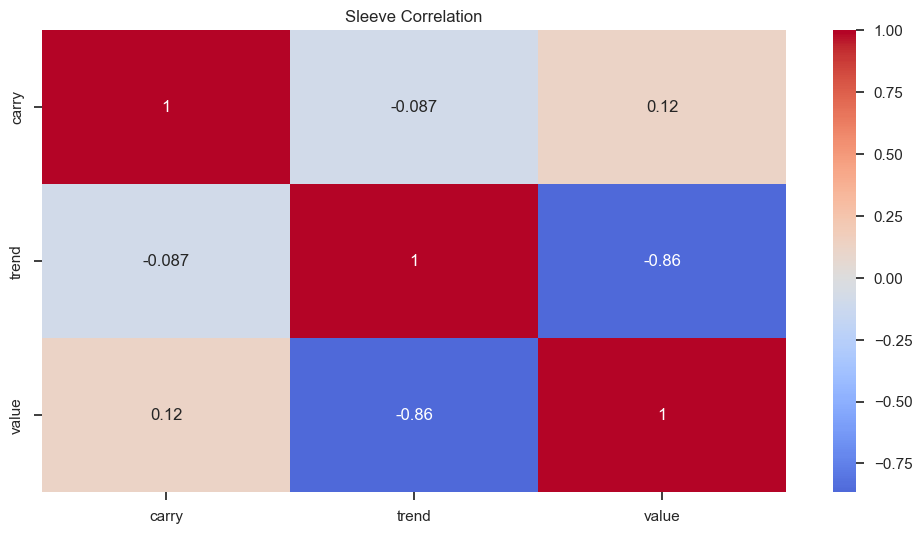

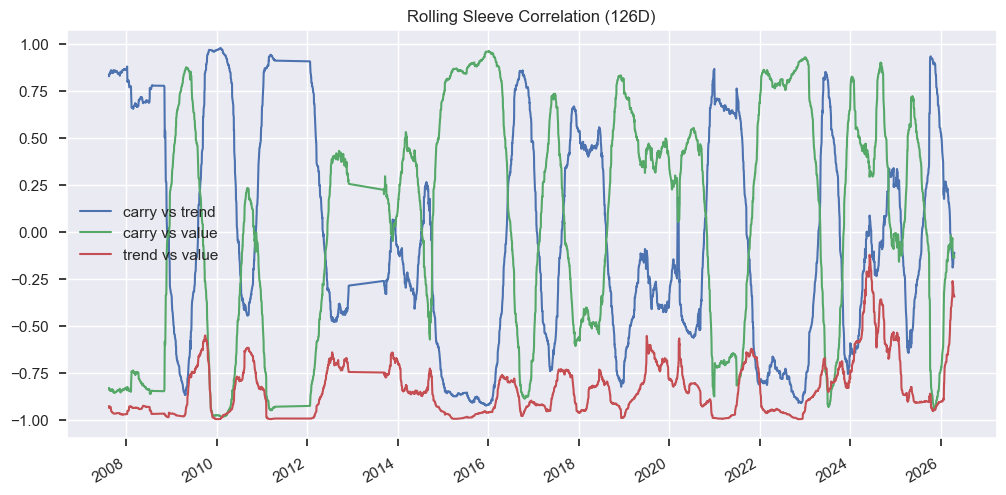

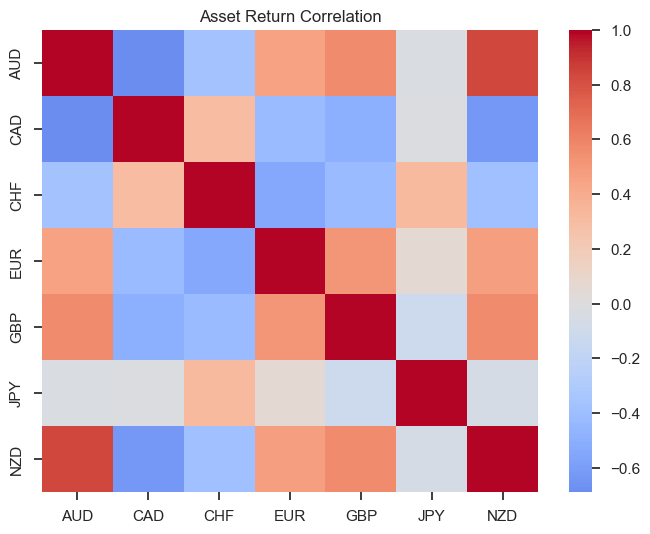

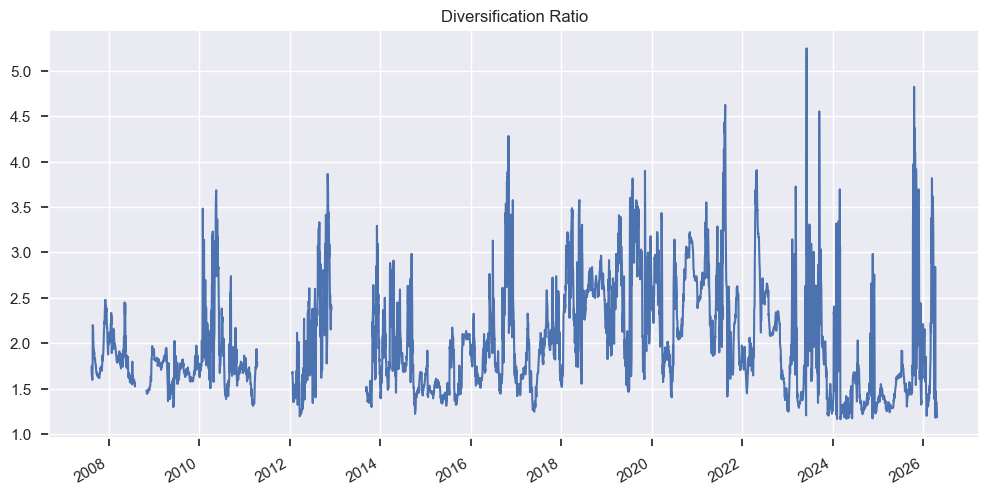

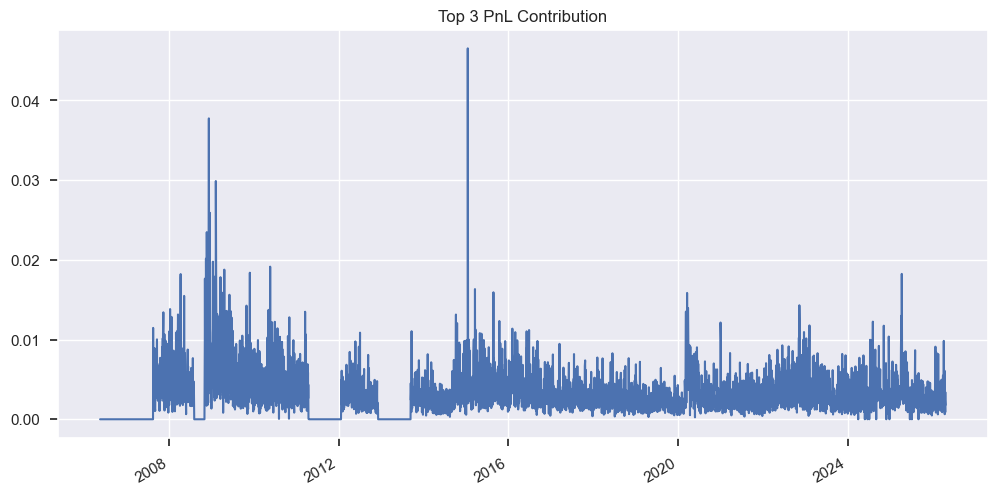

In [9]:
# Diversification Diagnostics

# SLEEVE CORRELATION MATRIX
def plot_sleeve_correlation(sleeve_pnls_df):
    corr = sleeve_pnls_df.corr()

    fig, ax = plt.subplots()
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax)

    ax.set_title("Sleeve Correlation")

    return fig

# ROLLING SLEEVE CORRELATION (PAIRWISE)
def plot_rolling_sleeve_correlation(sleeve_pnls_df, window=126):
    cols = sleeve_pnls_df.columns

    fig, ax = plt.subplots()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            pair = f"{cols[i]} vs {cols[j]}"
            rolling_corr = (
                sleeve_pnls_df[cols[i]]
                .rolling(window)
                .corr(sleeve_pnls_df[cols[j]])
            )
            rolling_corr.plot(ax=ax, label=pair)

    ax.set_title(f"Rolling Sleeve Correlation ({window}D)")
    ax.legend()
    ax.grid(True)

    return fig

# ASSET CORRELATION
def plot_asset_correlation(returns_df):
    corr = returns_df.corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)

    ax.set_title("Asset Return Correlation")

    return fig

# DIVERSIFICATION RATIO
def compute_diversification_ratio(weights, returns_df, window=126):
    ratios = []

    for t in range(window, len(weights)):
        w = weights.iloc[t]
        ret_window = returns_df.iloc[t-window:t]

        cov = ret_window.cov()
        vol = np.sqrt(np.diag(cov))

        numerator = np.dot(np.abs(w), vol)
        denominator = np.sqrt(np.dot(w, np.dot(cov, w)))

        if denominator != 0:
            ratios.append(numerator / denominator)
        else:
            ratios.append(np.nan)

    return pd.Series(ratios, index=weights.index[window:])

# PLOT DIVERSIFICATION RATIO
def plot_diversification_ratio(weights, returns_df, window=126):
    dr = compute_diversification_ratio(weights, returns_df, window)

    fig, ax = plt.subplots()
    dr.plot(ax=ax)

    ax.set_title("Diversification Ratio")
    ax.grid(True)

    return fig

# PNL CONTRIBUTION CONCENTRATION
def plot_pnl_concentration(weights, returns_df, top_n=3):
    pnl_contrib = weights.shift(1) * returns_df

    top_contrib = pnl_contrib.abs().apply(
        lambda row: row.nlargest(top_n).sum(),
        axis=1
    )

    fig, ax = plt.subplots()
    top_contrib.plot(ax=ax)

    ax.set_title(f"Top {top_n} PnL Contribution")
    ax.grid(True)

    return fig

sleeve_pnls = diag["sleeve_pnls"]
returns = diag["returns"]
weights = diag["weights"]

plot_sleeve_correlation(sleeve_pnls)
plot_rolling_sleeve_correlation(sleeve_pnls)

plot_asset_correlation(returns)

plot_diversification_ratio(weights, returns)

plot_pnl_concentration(weights, returns)

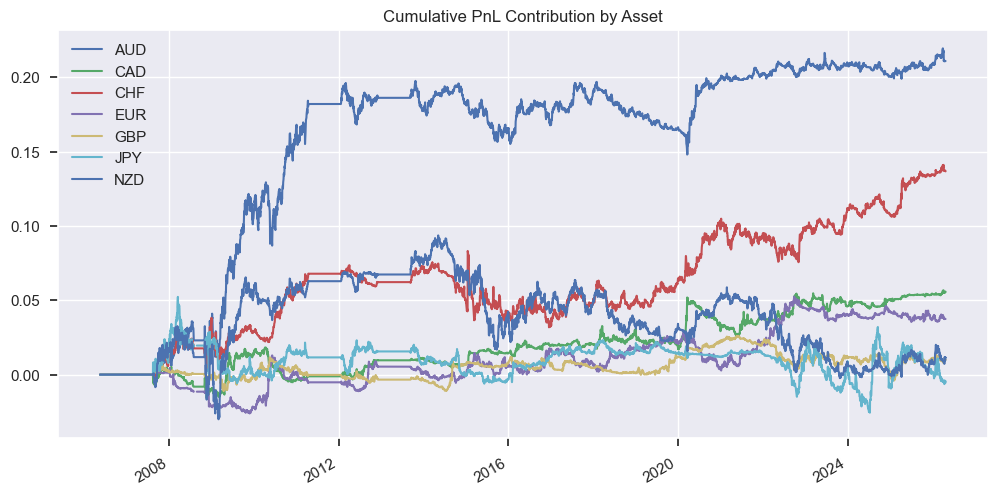

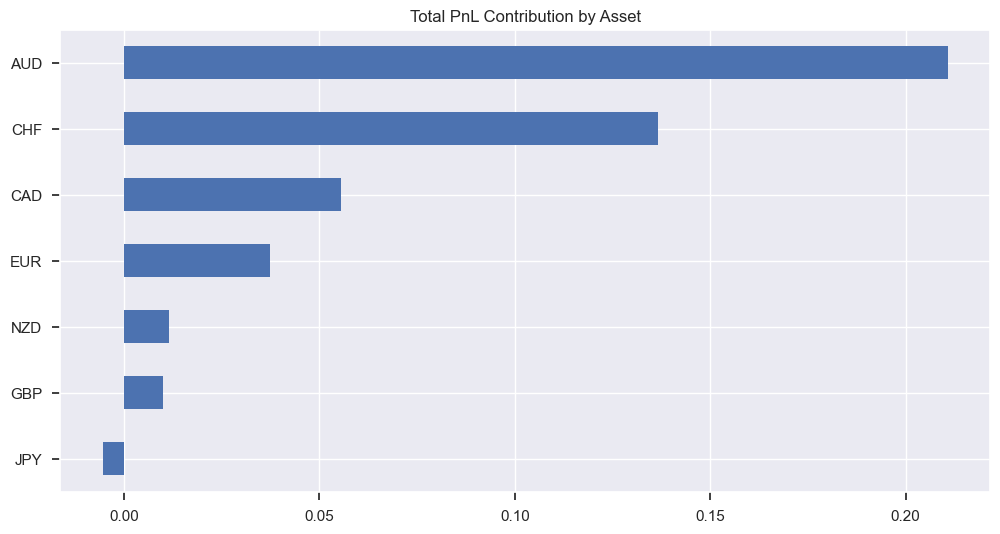

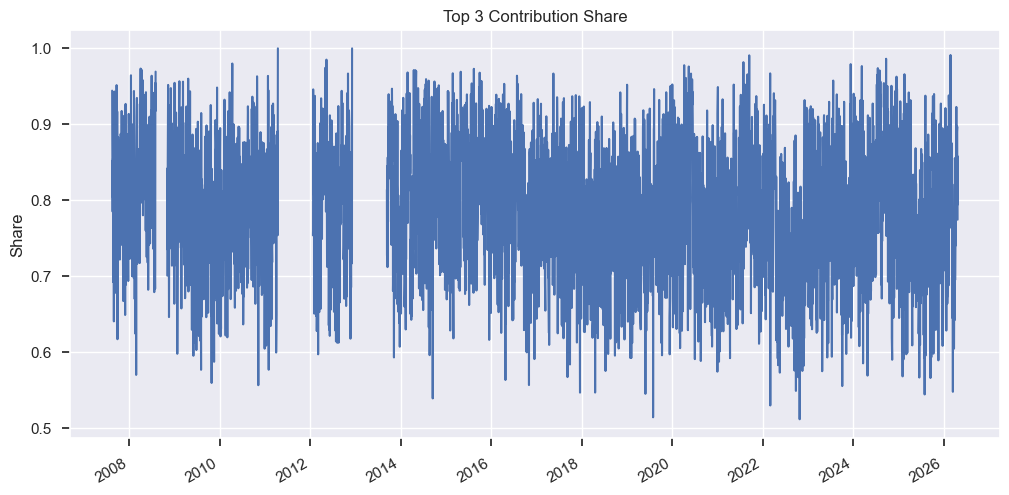

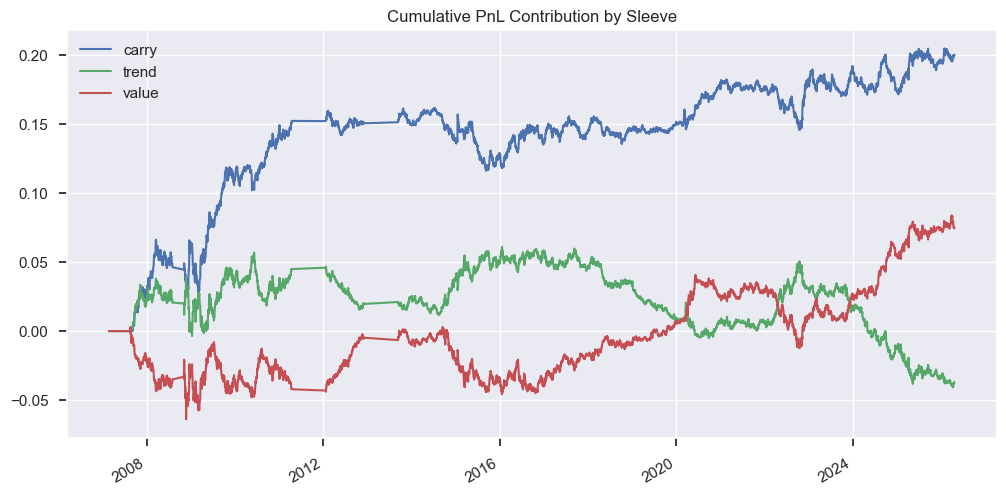

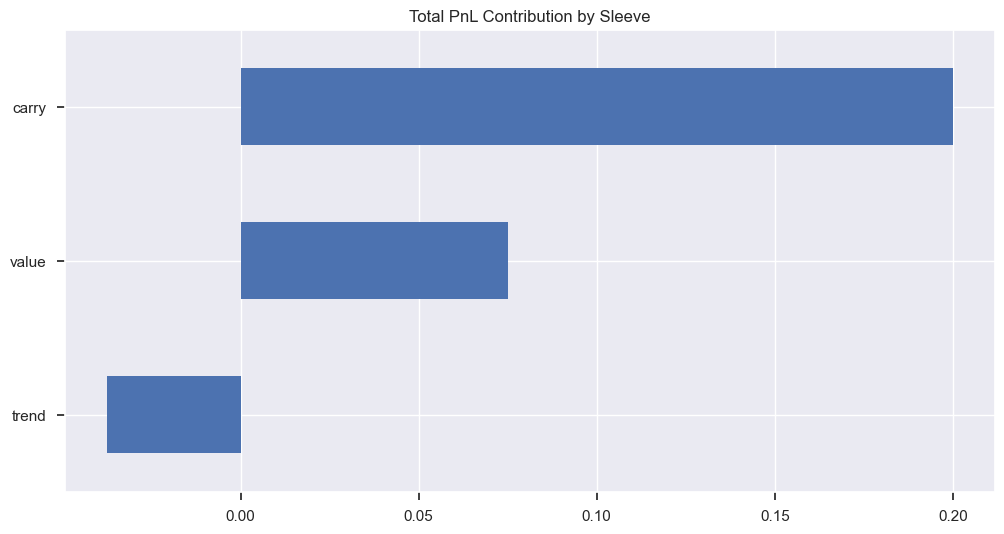

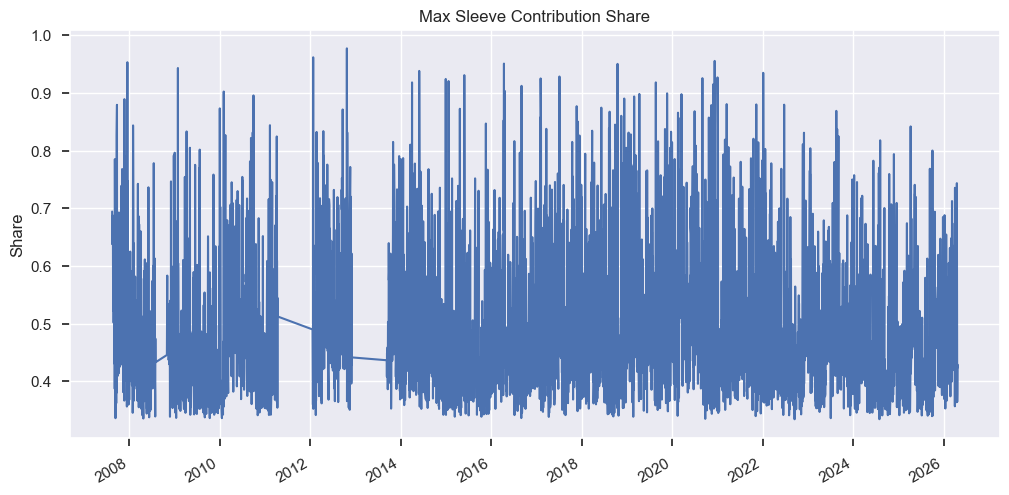

In [10]:
# Correlation Diagnostics

# ASSET PNL CONTRIBUTION (TIME SERIES)
def compute_asset_pnl_contribution(weights, returns_df):
    return weights.shift(1) * returns_df

def plot_asset_pnl_contribution(asset_pnl):
    fig, ax = plt.subplots()

    asset_pnl.cumsum().plot(ax=ax)

    ax.set_title("Cumulative PnL Contribution by Asset")
    ax.grid(True)

    return fig

# TOTAL PNL CONTRIBUTION BY ASSET
def plot_total_asset_contribution(asset_pnl):
    total = asset_pnl.sum().sort_values()

    fig, ax = plt.subplots()
    total.plot(kind="barh", ax=ax)

    ax.set_title("Total PnL Contribution by Asset")

    return fig

# TOP-N CONTRIBUTION SHARE
def plot_top_asset_concentration(asset_pnl, top_n=3):
    abs_contrib = asset_pnl.abs()

    top = abs_contrib.apply(
        lambda row: row.nlargest(top_n).sum(),
        axis=1
    )

    total = abs_contrib.sum(axis=1)

    share = top / total

    fig, ax = plt.subplots()
    share.plot(ax=ax)

    ax.set_title(f"Top {top_n} Contribution Share")
    ax.set_ylabel("Share")
    ax.grid(True)

    return fig

# SLEEVE PNL CONTRIBUTION
def compute_sleeve_contribution(sleeve_alloc, sleeve_pnls_df):
    # align
    common_idx = sleeve_alloc.index.intersection(sleeve_pnls_df.index)

    alloc = sleeve_alloc.loc[common_idx]
    pnl = sleeve_pnls_df.loc[common_idx]

    return alloc.shift(1) * pnl

def plot_sleeve_contribution(sleeve_contrib):
    fig, ax = plt.subplots()

    sleeve_contrib.cumsum().plot(ax=ax)

    ax.set_title("Cumulative PnL Contribution by Sleeve")
    ax.grid(True)

    return fig

def plot_total_sleeve_contribution(sleeve_contrib):
    total = sleeve_contrib.sum().sort_values()

    fig, ax = plt.subplots()
    total.plot(kind="barh", ax=ax)

    ax.set_title("Total PnL Contribution by Sleeve")

    return fig

# MAX SLEEVE CONTRIBUTION SHARE
def plot_sleeve_dominance(sleeve_contrib):
    abs_contrib = sleeve_contrib.abs()

    max_share = abs_contrib.max(axis=1) / abs_contrib.sum(axis=1)

    fig, ax = plt.subplots()
    max_share.plot(ax=ax)

    ax.set_title("Max Sleeve Contribution Share")
    ax.set_ylabel("Share")
    ax.grid(True)

    return fig

weights = diag["weights"]
returns = diag["returns"]
sleeve_alloc = diag["sleeve_alloc"]
sleeve_pnls = diag["sleeve_pnls"]

# asset level
asset_pnl = compute_asset_pnl_contribution(weights, returns)

plot_asset_pnl_contribution(asset_pnl)
plot_total_asset_contribution(asset_pnl)
plot_top_asset_concentration(asset_pnl)

# sleeve level
if sleeve_alloc is not None and sleeve_pnls is not None:
    sleeve_contrib = compute_sleeve_contribution(sleeve_alloc, sleeve_pnls)

    plot_sleeve_contribution(sleeve_contrib)
    plot_total_sleeve_contribution(sleeve_contrib)
    plot_sleeve_dominance(sleeve_contrib)

Sleeve              carry     trend     value
State                                        
commodity_state  0.054579  0.002362 -0.004906
equity_state     0.101788 -0.046872  0.035938
funding_state   -0.058461 -0.009906  0.017759
vol_state       -0.025709  0.004149  0.003147
equity_state {'High': {'PnL': np.float64(0.48024495051865435), 'Sharpe': np.float64(1.2829462187845333), 'Vol': np.float64(0.048627782230797376), 'MaxDD': -0.056403791434737394, 'Skew': np.float64(0.36949182285705673)}, 'Low': {'PnL': np.float64(-0.23795981127685828), 'Sharpe': np.float64(-1.1452583230814293), 'Vol': np.float64(0.04647305059932784), 'MaxDD': -0.2637808760771868, 'Skew': np.float64(0.327334705229726)}}
funding_state {'High': {'PnL': np.float64(-0.2353430300888093), 'Sharpe': np.float64(-1.9981609068930701), 'Vol': np.float64(0.05367445424493804), 'MaxDD': -0.25204300344261676, 'Skew': np.float64(0.2525071989693967)}, 'Low': {'PnL': np.float64(0.16760486385288242), 'Sharpe': np.float64(2.821621909180

/var/folders/ps/45m3y3115p7b5b6r4qyk36pr0000gn/T/ipykernel_8073/3596889189.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = y.groupby(bins).mean()
/var/folders/ps/45m3y3115p7b5b6r4qyk36pr0000gn/T/ipykernel_8073/3596889189.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = y.groupby(bins).mean()
/var/folders/ps/45m3y3115p7b5b6r4qyk36pr0000gn/T/ipykernel_8073/3596889189.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default an

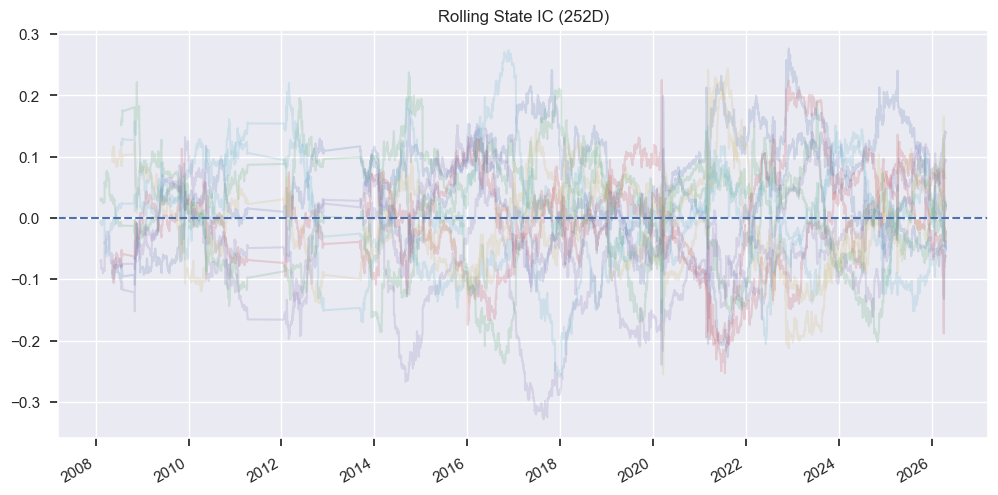

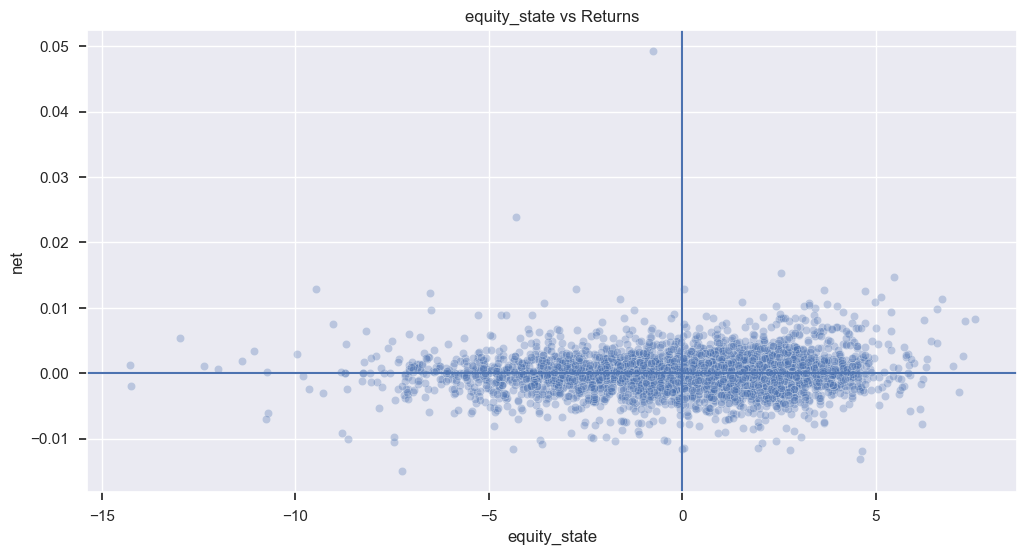

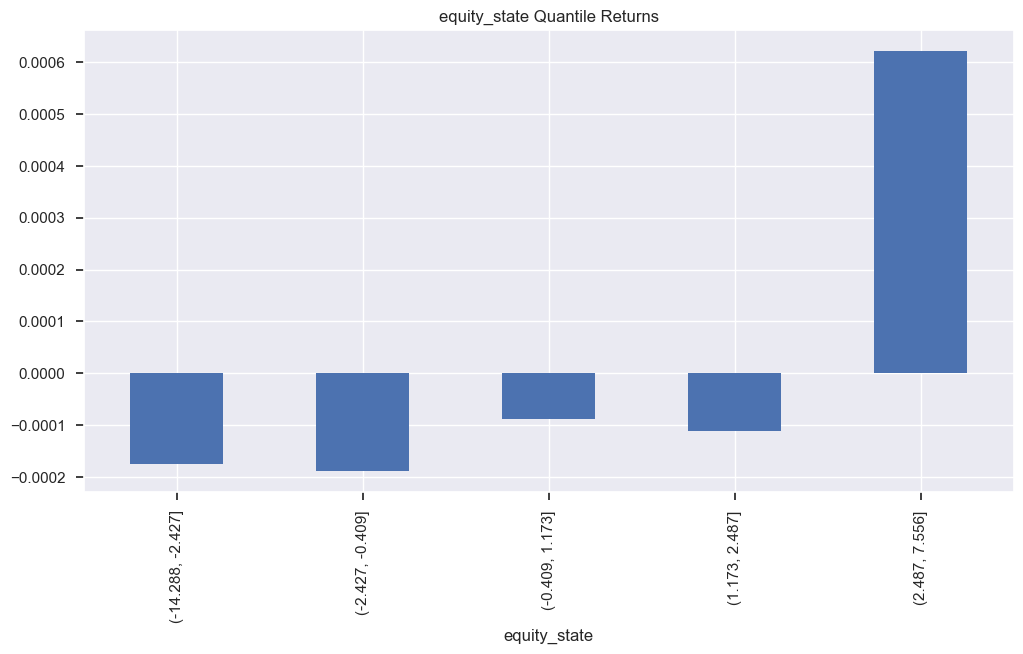

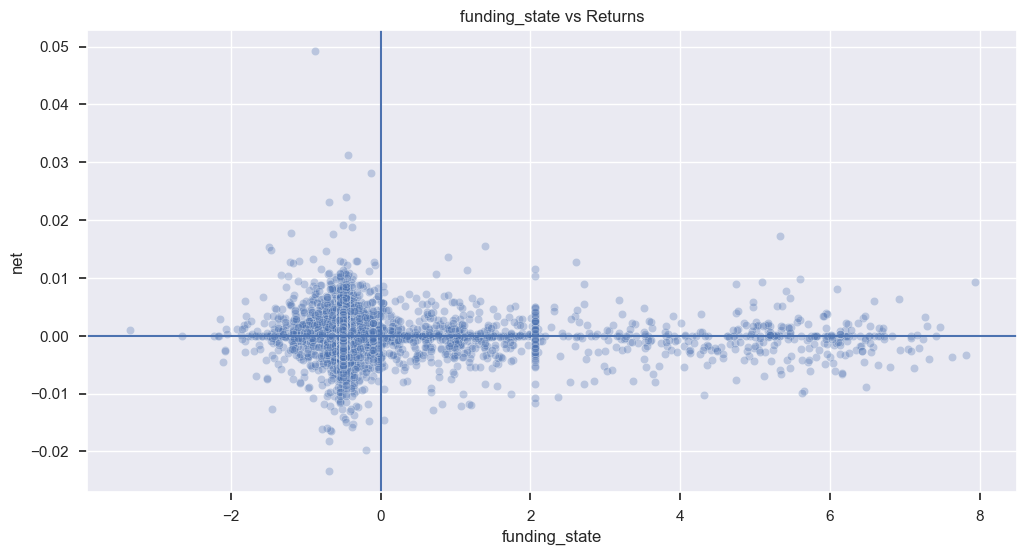

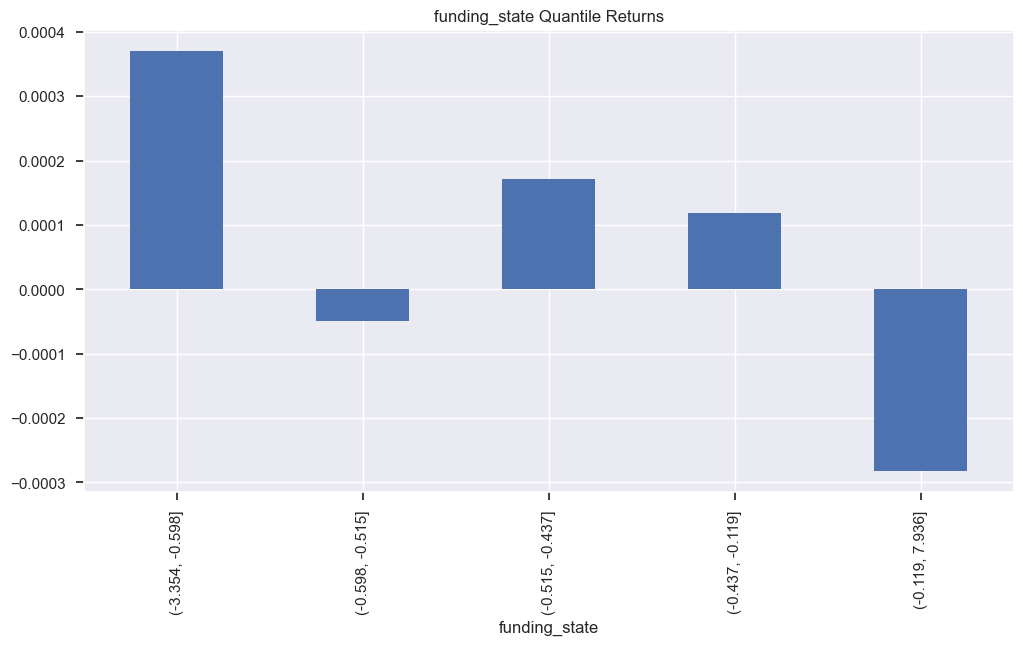

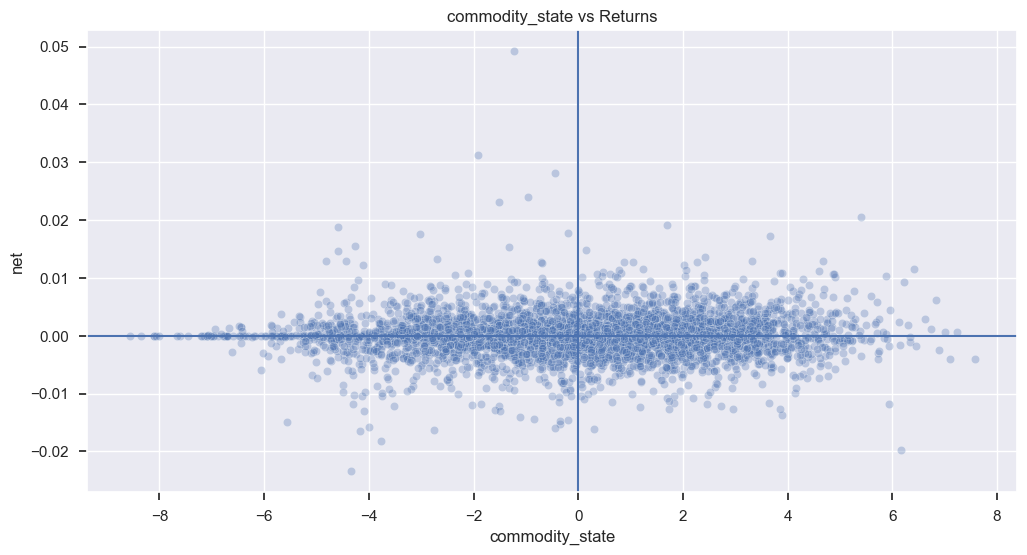

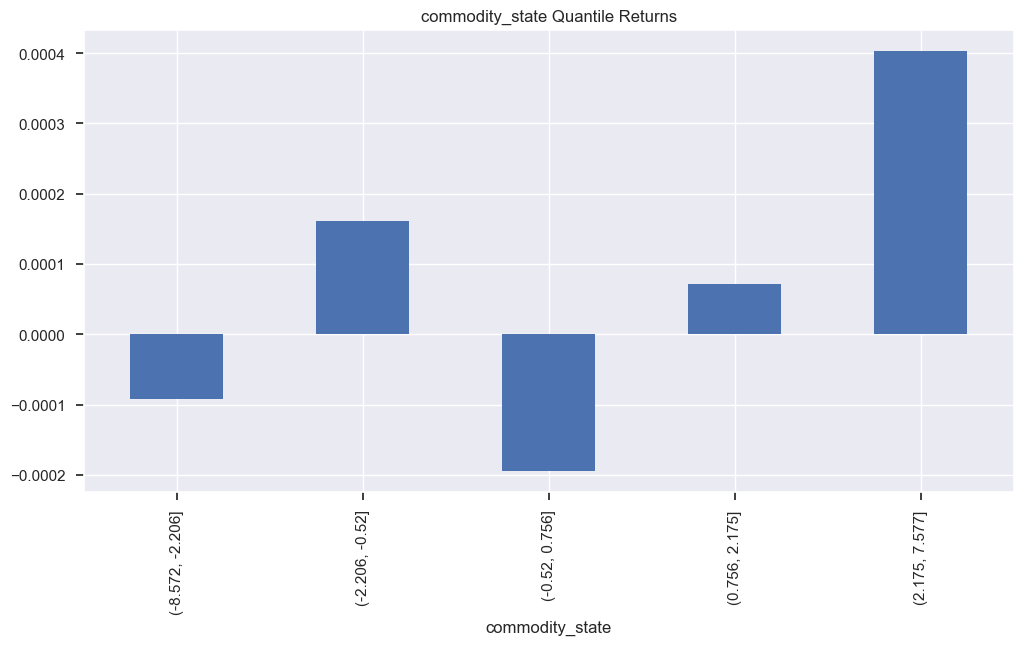

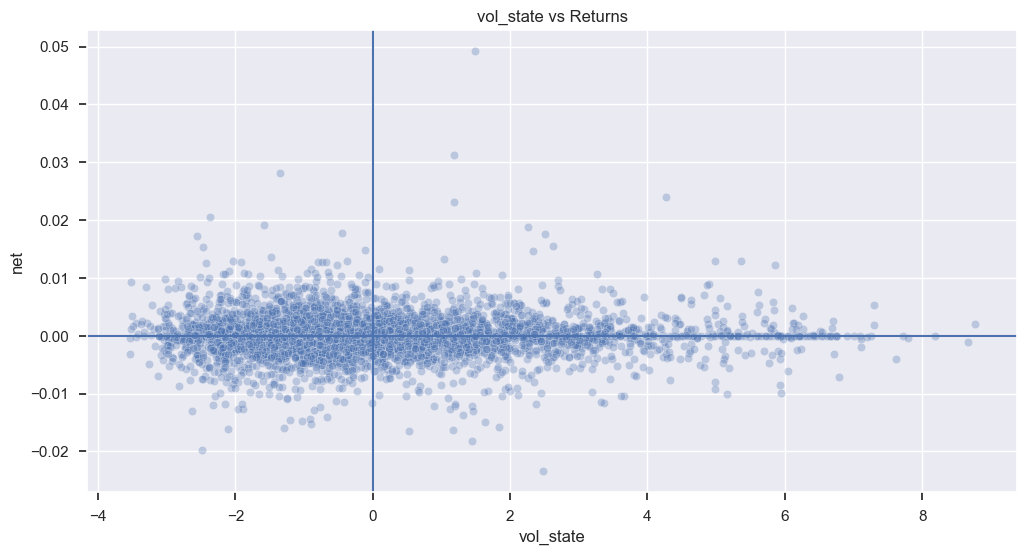

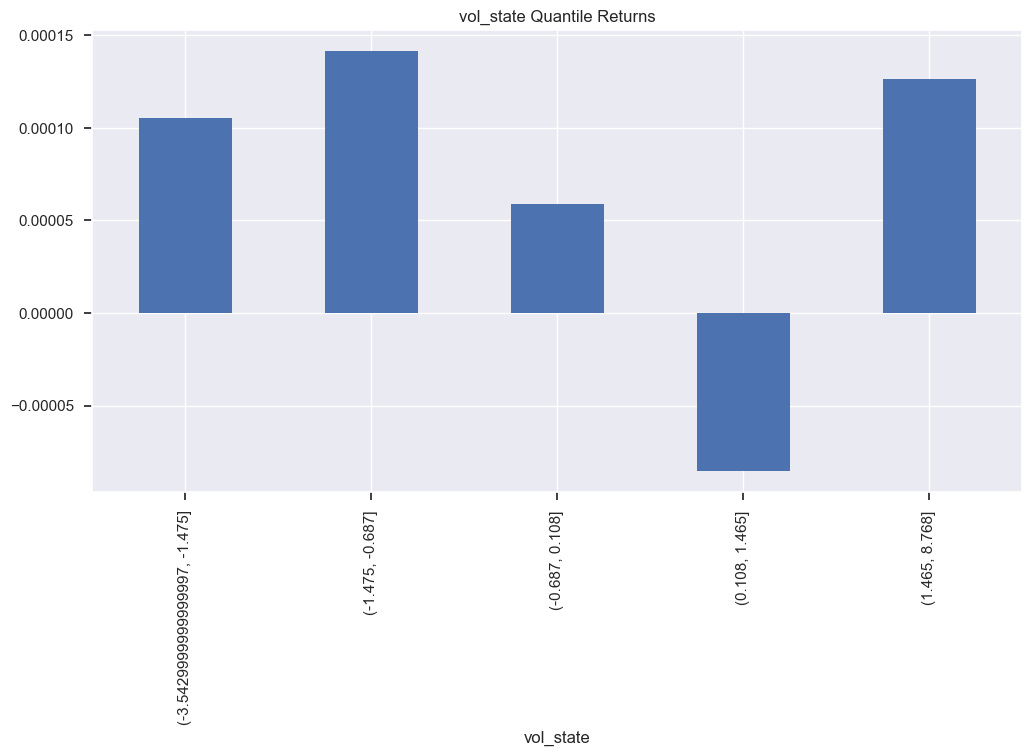

In [13]:
# ============================================
# REGIME / CONDITIONING DIAGNOSTICS
# ============================================

# ROLLING IC: STATE vs SLEEVE RETURNS
def plot_state_ic(states_df, sleeve_pnls, window=252):
    fig, ax = plt.subplots()

    for sleeve_name, pnl in sleeve_pnls.items():
        for state in states_df.columns:
            common_idx = pnl.index.intersection(states_df.index)

            x = states_df.loc[common_idx, state]
            y = pnl.loc[common_idx]

            if x.std() == 0 or y.std() == 0:
                continue

            rolling_ic = x.rolling(window).corr(y)
            rolling_ic.plot(ax=ax, alpha=0.2)

    ax.axhline(0, linestyle="--")
    ax.set_title(f"Rolling State IC ({window}D)")
    ax.grid(True)

    return fig


# MEAN IC TABLE
def compute_state_ic_table(states_df, sleeve_pnls):
    rows = []

    for sleeve_name, pnl in sleeve_pnls.items():
        common_idx = pnl.index.intersection(states_df.index)

        for state in states_df.columns:
            x = states_df.loc[common_idx, state]
            y = pnl.loc[common_idx]

            if x.std() == 0 or y.std() == 0:
                continue

            ic = x.corr(y)

            rows.append({
                "Sleeve": sleeve_name,
                "State": state,
                "IC": ic
            })

    df = pd.DataFrame(rows)

    if df.empty:
        return None

    return df.pivot(index="State", columns="Sleeve", values="IC")


# STATE vs RETURNS SCATTER
def plot_state_vs_returns(states_df, pnl, state_name):
    if state_name not in states_df.columns:
        return None

    common_idx = pnl.index.intersection(states_df.index)

    x = states_df.loc[common_idx, state_name]
    y = pnl.loc[common_idx]

    fig, ax = plt.subplots()
    sns.scatterplot(x=x, y=y, alpha=0.3, ax=ax)

    ax.set_title(f"{state_name} vs Returns")
    ax.axhline(0)
    ax.axvline(0)

    return fig


# QUANTILE PERFORMANCE
def plot_state_quantile_performance(states_df, pnl, state_name, q=5):
    if state_name not in states_df.columns:
        return None

    common_idx = pnl.index.intersection(states_df.index)

    x = states_df.loc[common_idx, state_name]
    y = pnl.loc[common_idx]

    if x.nunique() < q:
        return None

    bins = pd.qcut(x, q, duplicates="drop")
    grouped = y.groupby(bins).mean()

    fig, ax = plt.subplots()
    grouped.plot(kind="bar", ax=ax)

    ax.set_title(f"{state_name} Quantile Returns")

    return fig


# PERFORMANCE BY STATE SIGN
def compute_state_split_performance(states_df, pnl, state_name):
    if state_name not in states_df.columns:
        return None

    common_idx = pnl.index.intersection(states_df.index)

    x = states_df.loc[common_idx, state_name]
    y = pnl.loc[common_idx]

    high = y[x > 1]
    low = y[x < -1]

    return {
        "High": performance_stats(high),
        "Low": performance_stats(low)
    }


# SCALAR EFFECTIVENESS
def compare_pre_post_scaling(sleeve_pnls, scaled_pnl):
    base = pd.concat(sleeve_pnls.values(), axis=1).mean(axis=1)

    return pd.DataFrame({
        "Base": performance_stats(base),
        "Scaled": performance_stats(scaled_pnl)
    })


# ============================================
# RUN DIAGNOSTICS
# ============================================

states_df = pd.read_parquet("data/states_df.parquet")
sleeve_pnls = diag["sleeve_pnls"]
pnl = diag["pnl"]["net"]

# 1. Rolling IC (global view)
plot_state_ic(states_df, sleeve_pnls)

# 2. IC table
ic_table = compute_state_ic_table(states_df, sleeve_pnls)
print(ic_table)

# 3. Select top states (no guessing)
if ic_table is not None:
    mean_ic = ic_table.abs().mean(axis=1)
    top_states = mean_ic.sort_values(ascending=False).head(5).index

    # 4. Detailed diagnostics only for top states
    for state in top_states:
        plot_state_vs_returns(states_df, pnl, state_name=state)
        plot_state_quantile_performance(states_df, pnl, state_name=state)
        print(state, compute_state_split_performance(states_df, pnl, state))

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


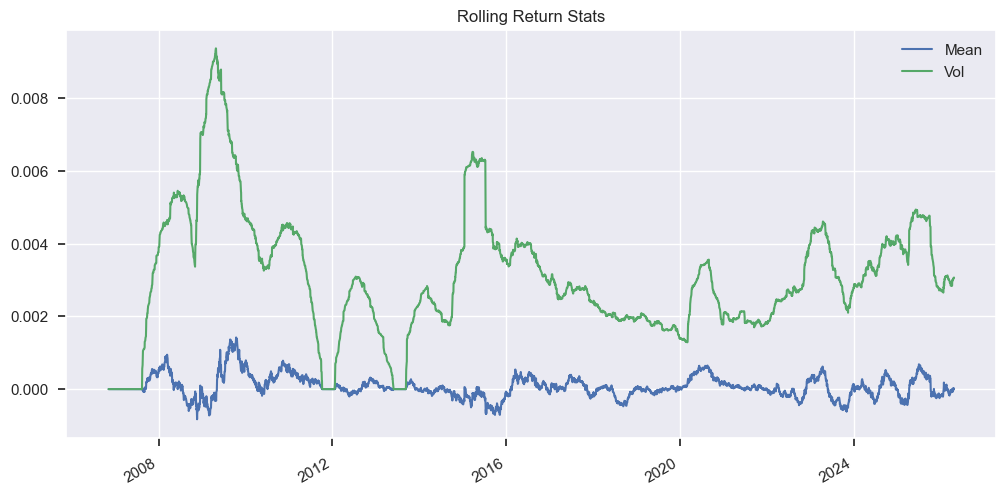

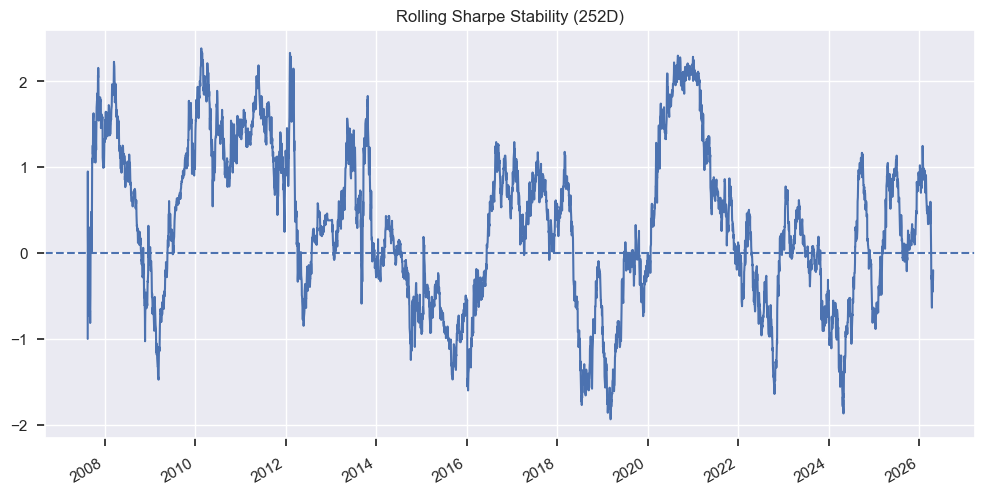

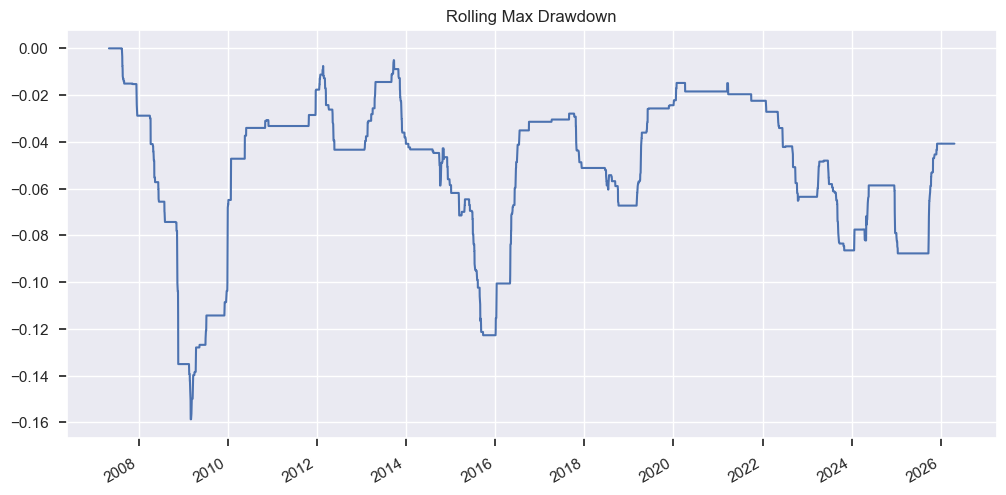

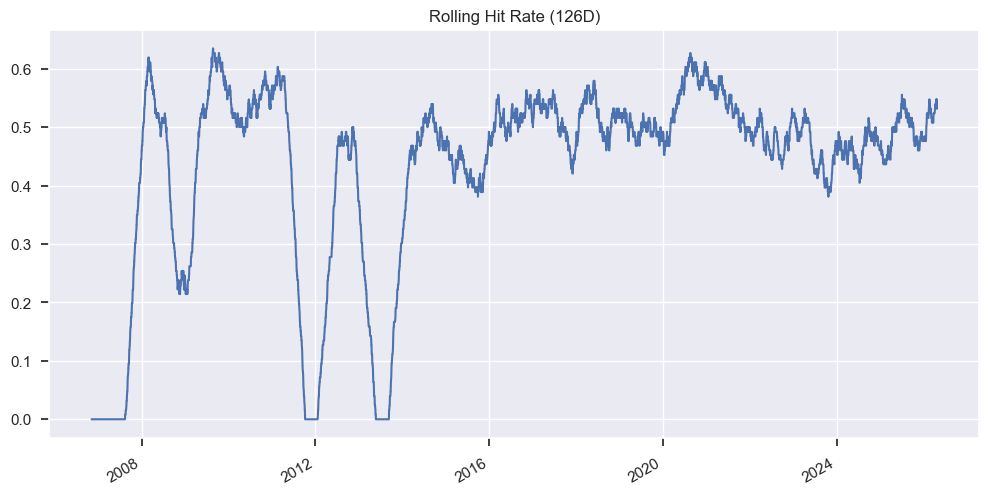

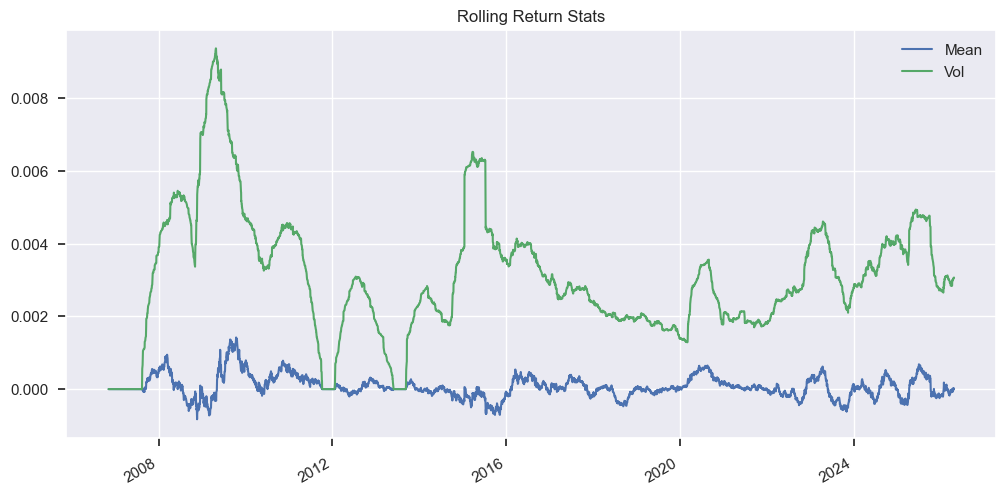

In [14]:
# Stability Diagnostics

# SUBPERIOD PERFORMANCE
def compute_subperiod_stats(pnl, n_splits=3):
    pnl = pnl.dropna()
    splits = np.array_split(pnl, n_splits)

    rows = []

    for i, s in enumerate(splits):
        stats = performance_stats(s)

        rows.append({
            "Period": f"Split_{i+1}",
            "Sharpe": stats["Sharpe"],
            "Vol": stats["Vol"],
            "MaxDD": stats["MaxDD"],
            "Return": stats["PnL"],
            "Start": s.index[0],
            "End": s.index[-1]
        })

    return pd.DataFrame(rows)

# ROLLING SHARPE STABILITY
def plot_rolling_sharpe_stability(pnl, window=252):
    rs = compute_rolling_sharpe(pnl, window)

    fig, ax = plt.subplots()
    rs.plot(ax=ax)

    ax.axhline(0, linestyle="--")
    ax.set_title(f"Rolling Sharpe Stability ({window}D)")
    ax.grid(True)

    return fig

# ROLLING MAX DRAWDOWN
def plot_rolling_drawdown(pnl, window=252):
    rolling_dd = []

    pnl = pnl.dropna()

    for i in range(window, len(pnl)):
        window_pnl = pnl.iloc[i-window:i]
        dd = compute_drawdown(window_pnl).min()
        rolling_dd.append(dd)

    rolling_dd = pd.Series(rolling_dd, index=pnl.index[window:])

    fig, ax = plt.subplots()
    rolling_dd.plot(ax=ax)

    ax.set_title("Rolling Max Drawdown")
    ax.grid(True)

    return fig

# ROLLING HIT RATE
def plot_rolling_hit_rate(pnl, window=126):
    hit = (pnl > 0).astype(int)
    hr = hit.rolling(window).mean()

    fig, ax = plt.subplots()
    hr.plot(ax=ax)

    ax.set_title(f"Rolling Hit Rate ({window}D)")
    ax.grid(True)

    return fig

# ROLLING MEAN AND VOL
def plot_rolling_return_stats(pnl, window=126):
    mean = pnl.rolling(window).mean()
    vol = pnl.rolling(window).std()

    fig, ax = plt.subplots()

    mean.plot(ax=ax, label="Mean")
    vol.plot(ax=ax, label="Vol")

    ax.set_title("Rolling Return Stats")
    ax.legend()
    ax.grid(True)

    return fig

# CRISIS VS NON-CRISIS
def compute_crisis_performance(pnl, vol_series, threshold=1.5):
    z = (vol_series - vol_series.mean()) / vol_series.std()

    crisis = pnl[z > threshold]
    normal = pnl[z <= threshold]

    return {
        "Crisis": performance_stats(crisis),
        "Normal": performance_stats(normal)
    }

pnl = diag["pnl"]["net"]

# 1. subperiods
compute_subperiod_stats(pnl)

# 2. rolling sharpe
plot_rolling_sharpe_stability(pnl)

# 3. rolling drawdown
plot_rolling_drawdown(pnl)

# 4. hit rate
plot_rolling_hit_rate(pnl)

# 5. return stability
plot_rolling_return_stats(pnl)